# T-GAN — Pipeline A
Transformer GAN for synthetic fraud generation → LightGBM classifier.

## 1. Dependencies

In [1]:
import time
import json
import warnings
import dataclasses
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import wandb
import lightgbm as lgb
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    matthews_corrcoef,
)
from imblearn.metrics import geometric_mean_score
from scipy.spatial.distance import jensenshannon
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
import torch.backends.cuda as cuda_backends

# Force standard (non-fused) attention — required for WGAN-GP gradient penalty
# backprop through TransformerEncoderLayer on this PyTorch build.
# The efficient/flash attention kernels don't implement the backward pass here.
torch.backends.cuda.enable_flash_sdp(False)
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)

## 2. W&B Login
Paste your API key from https://wandb.ai/settings

In [3]:
# On Kaggle: Settings → Internet → ON (required for W&B)
wandb.login(key='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')  # replace with your key


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kkipngenokoech (kkipngenokoech-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Load Feature Store Data

In [4]:
import os
from pathlib import Path

# ── Works locally AND on Colab/server without any changes ─────────────────
# Local:  checks ieee_feature_store/ at project root first; uses it if found
# Colab:  falls back to wget from GitHub if parquets are not present

if os.path.exists("/content"):
    STORE = Path("/content/ieee_feature_store")
else:
    _HERE = Path.cwd()
    # notebook lives at  <project_root>/notebooks/ieee/
    # feature store is at <project_root>/ieee_feature_store/
    _candidate = _HERE.parent.parent / "ieee_feature_store"
    STORE = _candidate if _candidate.exists() else _HERE / "ieee_feature_store"

STORE.mkdir(parents=True, exist_ok=True)

BASE = "https://raw.githubusercontent.com/kkipngenokoech/synthesize-or-reconstruct/main/ieee_feature_store"

for fname in ["pipeline_a_train.parquet", "pipeline_a_val.parquet",
              "pipeline_b_train.parquet", "holdout.parquet"]:
    out = STORE / fname
    if out.exists() and out.stat().st_size > 0:
        print(f"Found locally  : {fname}  ({out.stat().st_size / 1e6:.1f} MB)")
    else:
        if out.exists(): out.unlink()
        print(f"Downloading    : {fname} ...")
        ret = os.system(f'wget -q --show-progress -O "{out}" "{BASE}/{fname}"')
        if ret != 0 or out.stat().st_size == 0:
            out.unlink(missing_ok=True)
            raise RuntimeError(f"Download failed for {fname}. "
                               "Run ieee/pipeline.ipynb first and commit the parquets.")
        print(f"Downloaded     : {fname}  ({out.stat().st_size / 1e6:.1f} MB)")

print(f"\nIEEE feature store ready at: {STORE.resolve()}")
print("Files:", sorted(p.name for p in STORE.glob("*.parquet")))


Found locally  : pipeline_a_train.parquet  (6.0 MB)
Found locally  : pipeline_a_val.parquet  (1.5 MB)
Found locally  : pipeline_b_train.parquet  (5.8 MB)
Found locally  : holdout.parquet  (1.9 MB)

IEEE feature store ready at: /content/ieee_feature_store
Files: ['holdout.parquet', 'pipeline_a_train.parquet', 'pipeline_a_val.parquet', 'pipeline_b_train.parquet']


In [5]:
STORE = Path("/content/ieee_feature_store")

a_train = pd.read_parquet(STORE / 'pipeline_a_train.parquet')
a_val   = pd.read_parquet(STORE / 'pipeline_a_val.parquet')
holdout = pd.read_parquet(STORE / 'holdout.parquet')

print(f'Pipeline A train shape : {a_train.shape}')
print(f'Pipeline A val shape   : {a_val.shape}')
print(f'Holdout shape          : {holdout.shape}')
print(f'Pipeline A fraud rate  : {a_train["Class"].mean():.4%}')
print(f'Feature count          : {a_train.shape[1]}')

Pipeline A train shape : (377945, 17)
Pipeline A val shape   : (94487, 17)
Holdout shape          : (118108, 17)
Pipeline A fraud rate  : 3.4119%
Feature count          : 17


## 4. Configuration

In [6]:
@dataclass
class TGANConfig:
    # ── Data ──────────────────────────────────────────────────────────────
    target_col: str               = 'Class'
    n_features: int               = 51          # set dynamically below

    # ── Transformer architecture ───────────────────────────────────────────
    latent_dim: int               = 128
    d_model: int                  = 256
    nhead: int                    = 8
    num_encoder_layers_g: int     = 4
    num_encoder_layers_d: int     = 2
    dim_feedforward: int          = 512
    dropout: float                = 0.1
    seq_len: int                  = 8

    # ── GAN training ──────────────────────────────────────────────────────
    batch_size: int               = 256
    n_epochs: int                 = 260
    lr_g: float                   = 1e-4
    lr_d: float                   = 1e-4
    adam_beta1: float             = 0.5
    adam_beta2: float             = 0.9
    gp_lambda: float              = 1.0
    n_critic: int                 = 5

    # ── LightGBM ──────────────────────────────────────────────────────────
    lgb_num_leaves: int           = 63
    lgb_learning_rate: float      = 0.05
    lgb_n_estimators: int         = 500
    lgb_min_child_samples: int    = 20
    lgb_subsample: float          = 0.8
    lgb_colsample_bytree: float   = 0.8
    lgb_reg_alpha: float          = 0.1
    lgb_reg_lambda: float         = 0.1
    lgb_early_stopping_rounds: int = 50

    # ── Synthetic generation ───────────────────────────────────────────────
    n_synthetic_fraud: int        = 5000

    # ── Quality gate thresholds ────────────────────────────────────────────
    mmd_threshold: float          = 0.05
    jsd_threshold: float          = 0.1
    novelty_min_distance: float   = 0.01
    disc_auc_threshold: float     = 0.75


cfg = TGANConfig()
cfg.n_features = a_train.shape[1] - 1
print(f'Config: latent_dim={cfg.latent_dim}, d_model={cfg.d_model}, n_features={cfg.n_features}')

Config: latent_dim=128, d_model=256, n_features=16


## 5. Initialise W&B Run
Every field in `TGANConfig` is logged automatically.

In [7]:
run = wandb.init(
    project  = 'PRINCIPLES AND ENGINEERING  APPLICATIONS OF AI',
    name     = 'kip-tgan-pipeline-a-run-4',
    tags     = ['T-GAN', 'Pipeline-A', 'WGAN-GP', 'LightGBM'],
    config   = asdict(cfg),   # logs every param in TGANConfig
)

# Sync config back so wandb sweeps can override values
wcfg = wandb.config
cfg.latent_dim            = wcfg.latent_dim
cfg.d_model               = wcfg.d_model
cfg.nhead                 = wcfg.nhead
cfg.num_encoder_layers_g  = wcfg.num_encoder_layers_g
cfg.num_encoder_layers_d  = wcfg.num_encoder_layers_d
cfg.dim_feedforward       = wcfg.dim_feedforward
cfg.dropout               = wcfg.dropout
cfg.seq_len               = wcfg.seq_len
cfg.batch_size            = wcfg.batch_size
cfg.n_epochs              = wcfg.n_epochs
cfg.lr_g                  = wcfg.lr_g
cfg.lr_d                  = wcfg.lr_d
cfg.gp_lambda             = wcfg.gp_lambda
cfg.n_critic              = wcfg.n_critic
cfg.n_synthetic_fraud     = wcfg.n_synthetic_fraud
cfg.lgb_num_leaves        = wcfg.lgb_num_leaves
cfg.lgb_learning_rate     = wcfg.lgb_learning_rate
cfg.lgb_n_estimators      = wcfg.lgb_n_estimators
cfg.lgb_subsample         = wcfg.lgb_subsample
cfg.lgb_colsample_bytree  = wcfg.lgb_colsample_bytree
cfg.lgb_reg_alpha         = wcfg.lgb_reg_alpha
cfg.lgb_reg_lambda        = wcfg.lgb_reg_lambda

print('W&B run initialised:', run.name)
print('W&B project URL    :', run.url)


W&B run initialised: kip-tgan-pipeline-a-run-4
W&B project URL    : https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20%20APPLICATIONS%20OF%20AI/runs/hx2xzo4f


## 6. Data Preparation — Fraud-Only for T-GAN

In [8]:
# Time excluded per FIX 8 (Hayat & Magnier); GAN and LightGBM both use 15 features
MODEL_FEATURES = [f'C{i}' for i in range(1, 15)] + ['TransactionAmt']
FEATURE_COLS   = MODEL_FEATURES
GAN_FEATURES   = MODEL_FEATURES

fraud_train_gan = a_train[a_train[cfg.target_col] == 1][GAN_FEATURES].values.astype(np.float32)
N_REAL_FRAUD    = len(fraud_train_gan)
cfg.n_features  = len(GAN_FEATURES)           # 15
cfg.n_synthetic_fraud = int(N_REAL_FRAUD * 3) # 3x expansion

from sklearn.preprocessing import StandardScaler
gan_scaler         = StandardScaler()
fraud_train_scaled = np.clip(
    gan_scaler.fit_transform(fraud_train_gan).astype(np.float32), -5, 5
)

print(f'Fraud records for T-GAN : {N_REAL_FRAUD}')
print(f'Synthetic budget (3x)   : {cfg.n_synthetic_fraud}')
print(f'GAN features            : {len(GAN_FEATURES)}')
print(f'Scaled range: {fraud_train_scaled.min():.3f} to {fraud_train_scaled.max():.3f}')

fraud_tensor  = torch.tensor(fraud_train_scaled)
fraud_dataset = TensorDataset(fraud_tensor)
fraud_loader  = DataLoader(
    fraud_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True
)
print(f'Batches per epoch: {len(fraud_loader)}')

Fraud records for T-GAN : 12895
Synthetic budget (3x)   : 38685
GAN features            : 15
Scaled range: -0.686 to 5.000
Batches per epoch: 50


## 7. T-GAN Architecture

In [9]:
class TransformerGenerator(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.seq_len = cfg.seq_len
        self.d_model = cfg.d_model
        self.input_proj = nn.Linear(cfg.latent_dim, cfg.seq_len * cfg.d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.nhead,
            dim_feedforward=cfg.dim_feedforward,
            dropout=cfg.dropout, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_encoder_layers_g)
        self.output_proj  = nn.Sequential(
            nn.Linear(cfg.seq_len * cfg.d_model, 512),
            nn.ReLU(),
            nn.Linear(512, cfg.n_features)
            # No Tanh — real features are NOT bounded to [-1,1]
        )

    def forward(self, z):
        x = self.input_proj(z).view(-1, self.seq_len, self.d_model)
        x = self.transformer(x).reshape(x.size(0), -1)
        return self.output_proj(x)


class TransformerDiscriminator(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.seq_len = cfg.seq_len
        self.d_model = cfg.d_model
        self.input_proj = nn.Linear(cfg.n_features, cfg.seq_len * cfg.d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.nhead // 2,
            dim_feedforward=cfg.dim_feedforward // 2,
            dropout=cfg.dropout, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=cfg.num_encoder_layers_d)
        self.output_proj  = nn.Sequential(
            nn.Linear(cfg.d_model, 128), nn.LeakyReLU(0.2), nn.Linear(128, 1)
        )

    def forward(self, x):
        h = self.input_proj(x).view(-1, self.seq_len, self.d_model)
        h = self.transformer(h).mean(dim=1)
        return self.output_proj(h)


G = TransformerGenerator(cfg).to(DEVICE)
D = TransformerDiscriminator(cfg).to(DEVICE)

n_params_g = sum(p.numel() for p in G.parameters())
n_params_d = sum(p.numel() for p in D.parameters())
print(f'Generator params    : {n_params_g:,}')
print(f'Discriminator params: {n_params_d:,}')

wandb.log({
    'model/generator_params'    : n_params_g,
    'model/discriminator_params': n_params_d,
    'model/total_params'        : n_params_g + n_params_d,
})

Generator params    : 3,429,391
Discriminator params: 857,345


## 8. WGAN-GP Training Loop

In [10]:
def weights_init(m):
    """Xavier init for Linear layers — prevents loss explosion."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

G.apply(weights_init)
D.apply(weights_init)
print('Weights initialised.')

opt_G = optim.Adam(G.parameters(), lr=cfg.lr_g, betas=(cfg.adam_beta1, cfg.adam_beta2))
opt_D = optim.Adam(D.parameters(), lr=cfg.lr_d, betas=(cfg.adam_beta1, cfg.adam_beta2))


def compute_gradient_penalty(D, real, fake, device):
    bs    = real.size(0)
    alpha = torch.rand(bs, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = D(interp)
    grads = torch.autograd.grad(
        outputs=d_interp, inputs=interp,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True, retain_graph=True
    )[0]
    return ((grads.view(bs, -1).norm(2, dim=1) - 1) ** 2).mean()


def train_tgan(G, D, loader, cfg, device):
    G.train(); D.train()
    history = {'g_loss': [], 'd_loss': [], 'gp': []}

    for epoch in range(cfg.n_epochs):
        g_losses, d_losses, gp_vals = [], [], []

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            bs = real_batch.size(0)

            # Discriminator — n_critic steps
            for _ in range(cfg.n_critic):
                z    = torch.randn(bs, cfg.latent_dim, device=device)
                fake = G(z).detach()
                gp   = compute_gradient_penalty(D, real_batch, fake, device)
                d_loss = D(fake).mean() - D(real_batch).mean() + cfg.gp_lambda * gp
                opt_D.zero_grad()
                d_loss.backward()
                torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
                opt_D.step()

            d_losses.append(d_loss.item())
            gp_vals.append(gp.item())

            # Generator — one step
            z      = torch.randn(bs, cfg.latent_dim, device=device)
            g_loss = -D(G(z)).mean()
            opt_G.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            opt_G.step()
            g_losses.append(g_loss.item())

        mean_g  = np.mean(g_losses)
        mean_d  = np.mean(d_losses)
        mean_gp = np.mean(gp_vals)
        history['g_loss'].append(mean_g)
        history['d_loss'].append(mean_d)
        history['gp'].append(mean_gp)

        # ── W&B: log every epoch ──────────────────────────────────────────
        wandb.log({
            'train/epoch'               : epoch + 1,
            'train/g_loss'              : mean_g,
            'train/d_loss'              : mean_d,
            'train/gradient_penalty'    : mean_gp,
            'train/wasserstein_distance': -mean_d,   # proxy: -(d_fake - d_real)
            'train/g_d_ratio'           : abs(mean_g / (mean_d + 1e-8)),
        }, step=epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'Epoch [{epoch+1:3d}/{cfg.n_epochs}] '
                f'G: {mean_g:+.4f} | D: {mean_d:+.4f} | GP: {mean_gp:.4f}'
            )

    return history


print('Starting T-GAN training...')
t0 = time.time()
history = train_tgan(G, D, fraud_loader, cfg, DEVICE)
train_time_min = (time.time() - t0) / 60
print(f'Training complete in {train_time_min:.1f} min')

wandb.log({'train/total_time_min': train_time_min})

Weights initialised.
Starting T-GAN training...
Epoch [ 10/260] G: +98.2863 | D: -1.1760 | GP: 0.7115
Epoch [ 20/260] G: +96.9578 | D: -0.6024 | GP: 0.3777
Epoch [ 30/260] G: +133.3383 | D: +15.8626 | GP: 17.3005
Epoch [ 40/260] G: +946.6394 | D: +35615.7248 | GP: 35627.2005
Epoch [ 50/260] G: +1899.8350 | D: +352507.2375 | GP: 352536.0143
Epoch [ 60/260] G: +3035.2715 | D: +3376.5189 | GP: 3383.6755
Epoch [ 70/260] G: +3154.0581 | D: -0.6243 | GP: 0.1059
Epoch [ 80/260] G: +3244.1670 | D: +2342.4042 | GP: 2348.8112
Epoch [ 90/260] G: +4210.8075 | D: +56129.6101 | GP: 56142.8486
Epoch [100/260] G: +5294.5474 | D: +80.3459 | GP: 96.0512
Epoch [110/260] G: +6580.2796 | D: +10244.0609 | GP: 10267.5592
Epoch [120/260] G: +8100.2614 | D: +5259.8701 | GP: 5290.0869
Epoch [130/260] G: +9575.8490 | D: +3838.3420 | GP: 3872.5160
Epoch [140/260] G: +11259.5430 | D: +1636407.7913 | GP: 1636448.4246
Epoch [150/260] G: +13944.2694 | D: +3275041.3778 | GP: 3275167.2854
Epoch [160/260] G: +15658.9015

## 9. Generate Synthetic Fraud Samples

In [12]:
def generate_synthetic_fraud(G, cfg, n_samples, device, scaler):
    """T-GAN generates GAN_FEATURES (C1-C14 + TransactionAmt) directly."""
    G.eval()
    all_samples = []
    with torch.no_grad():
        remaining = n_samples
        while remaining > 0:
            batch = min(remaining, 1024)
            z = torch.randn(batch, cfg.latent_dim, device=device)
            all_samples.append(G(z).cpu().numpy())
            remaining -= batch
    arr = np.vstack(all_samples)[:n_samples]
    arr = scaler.inverse_transform(arr)
    df  = pd.DataFrame(arr, columns=GAN_FEATURES)
    df['Class'] = 1
    return df[GAN_FEATURES + ['Class']]


synthetic_fraud = generate_synthetic_fraud(G, cfg, cfg.n_synthetic_fraud, DEVICE, gan_scaler)
print(f'Synthetic fraud shape: {synthetic_fraud.shape}')
print(f'Synthetic range: {synthetic_fraud[GAN_FEATURES].min().min():.1f} to '
      f'{synthetic_fraud[GAN_FEATURES].max().max():.1f}')

syn_stats = synthetic_fraud[GAN_FEATURES].describe()
wandb.log({
    'synthetic/n_samples'  : len(synthetic_fraud),
    'synthetic/amount_mean': float(syn_stats.loc['mean', 'TransactionAmt']),
    'synthetic/amount_std' : float(syn_stats.loc['std',  'TransactionAmt']),
})

Synthetic fraud shape: (38685, 16)
Synthetic range: -512.1 to 1854.0


## 10. Synthetic Quality Gates

In [13]:
# Quality gates are INFORMATIONAL ONLY — pipeline continues regardless.
def _compute_mmd(real, synthetic, gamma=1.0):
    cap = 500
    rng = np.random.default_rng(GLOBAL_SEED)
    r = real[rng.choice(len(real), min(cap, len(real)), replace=False)]
    s = synthetic[rng.choice(len(synthetic), min(cap, len(synthetic)), replace=False)]
    def rbf(A, B):
        return np.exp(-gamma * np.sum((A[:, None, :] - B[None, :, :]) ** 2, axis=-1)).mean()
    return float(rbf(r, r) - 2 * rbf(r, s) + rbf(s, s))

def _compute_jsd(real, synthetic, n_bins=50):
    scores = []
    for i in range(real.shape[1]):
        combined = np.concatenate([real[:, i], synthetic[:, i]])
        bins = np.linspace(combined.min(), combined.max(), n_bins + 1)
        r_prob = np.histogram(real[:, i],      bins=bins, density=True)[0]
        s_prob = np.histogram(synthetic[:, i], bins=bins, density=True)[0]
        r_prob /= r_prob.sum() + 1e-12
        s_prob /= s_prob.sum() + 1e-12
        scores.append(float(jensenshannon(r_prob, s_prob)))
    return float(np.mean(scores))

def _novelty_check(real, synthetic, min_dist=0.01, cap=200):
    rng = np.random.default_rng(GLOBAL_SEED)
    r = real[rng.choice(len(real), min(cap, len(real)), replace=False)]
    s = synthetic[rng.choice(len(synthetic), min(cap, len(synthetic)), replace=False)]
    dists = np.sqrt(np.sum((s[:, None, :] - r[None, :, :]) ** 2, axis=-1)).min(axis=1)
    mean_min = float(dists.mean())
    return mean_min >= min_dist, mean_min

def _discriminability_check(real, synthetic, auc_threshold=0.75):
    X = np.vstack([real, synthetic])
    y = np.array([0] * len(real) + [1] * len(synthetic))
    X_sc = StandardScaler().fit_transform(X)
    clf  = LogisticRegression(max_iter=500, random_state=GLOBAL_SEED, class_weight='balanced')
    clf.fit(X_sc, y)
    auc = float(roc_auc_score(y, clf.predict_proba(X_sc)[:, 1]))
    return auc <= auc_threshold, auc

# Use training fraud records (not holdout) for quality gate evaluation
fraud_train_full = a_train[a_train['Class'] == 1].reset_index(drop=True)
real_arr = fraud_train_full[GAN_FEATURES].values.astype(np.float64)
syn_arr  = synthetic_fraud[GAN_FEATURES].values.astype(np.float64)

mmd              = _compute_mmd(real_arr, syn_arr)
jsd              = _compute_jsd(real_arr, syn_arr)
nov_pass, nov    = _novelty_check(real_arr, syn_arr)
disc_pass, dauc  = _discriminability_check(real_arr, syn_arr)

mmd_pass = mmd  <= cfg.mmd_threshold
jsd_pass = jsd  <= cfg.jsd_threshold
overall  = all([mmd_pass, jsd_pass, nov_pass, disc_pass])

print(
    f'[Synthetic Quality Gates -- INFORMATIONAL ONLY]\n'
    f'  MMD          : {mmd:.6f}  | Threshold <= {cfg.mmd_threshold}   | {"PASS" if mmd_pass else "FAIL"}\n'
    f'  JSD (mean)   : {jsd:.6f}  | Threshold <= {cfg.jsd_threshold}    | {"PASS" if jsd_pass else "FAIL"}\n'
    f'  Novelty dist : {nov:.6f} | Threshold >= {cfg.novelty_min_distance}  | {"PASS" if nov_pass else "FAIL"}\n'
    f'  Disc. AUC    : {dauc:.4f}   | Threshold <= {cfg.disc_auc_threshold}  | {"PASS" if disc_pass else "FAIL"}\n'
    f'  Overall      : {"PASS" if overall else "FAIL (informational — pipeline continues regardless)"}'
)

wandb.log({
    'quality_gates/mmd'               : mmd,
    'quality_gates/jsd_mean'          : jsd,
    'quality_gates/novelty_min_dist'  : nov,
    'quality_gates/discriminator_auc' : dauc,
    'quality_gates/overall_pass'      : int(overall),
})

[Synthetic Quality Gates -- INFORMATIONAL ONLY]
  MMD          : 0.015086  | Threshold <= 0.05   | PASS
  JSD (mean)   : 0.129932  | Threshold <= 0.1    | FAIL
  Novelty dist : 98.990148 | Threshold >= 0.01  | PASS
  Disc. AUC    : 1.0000   | Threshold <= 0.75  | FAIL
  Overall      : FAIL (informational — pipeline continues regardless)


## 11. Build Augmented Training Set for LightGBM

In [14]:
augmented_train = pd.concat(
    [a_train[MODEL_FEATURES + ['Class']], synthetic_fraud[GAN_FEATURES + ['Class']]],
    ignore_index=True
).sample(frac=1, random_state=GLOBAL_SEED).reset_index(drop=True)

X_train_lgb = augmented_train[MODEL_FEATURES]
y_train_lgb = augmented_train['Class']
X_val_lgb   = a_val[MODEL_FEATURES]
y_val_lgb   = a_val['Class']

aug_fraud_rate = y_train_lgb.mean()
print(f'Augmented train: {augmented_train.shape} | Fraud rate: {aug_fraud_rate:.4%}')

wandb.log({
    'lgb/augmented_train_size': len(augmented_train),
    'lgb/augmented_fraud_rate': aug_fraud_rate,
})

Augmented train: (416630, 16) | Fraud rate: 12.3803%


## 12. LightGBM Classifier

In [15]:
lgb_params = {
    'objective'        : 'binary',
    'metric'           : ['average_precision'],   # single metric avoids early stopping at round 1
    'boosting_type'    : 'gbdt',
    'num_leaves'       : cfg.lgb_num_leaves,
    'max_depth'        : -1,
    'learning_rate'    : cfg.lgb_learning_rate,
    'n_estimators'     : cfg.lgb_n_estimators,
    'min_child_samples': cfg.lgb_min_child_samples,
    'subsample'        : cfg.lgb_subsample,
    'colsample_bytree' : cfg.lgb_colsample_bytree,
    'reg_alpha'        : cfg.lgb_reg_alpha,
    'reg_lambda'       : cfg.lgb_reg_lambda,
    'is_unbalance'     : True,
    'random_state'     : GLOBAL_SEED,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

class WandbLGBCallback:
    def __call__(self, env):
        log = {}
        for data_name, metric_name, value, _ in env.evaluation_result_list:
            log[f'lgb/{data_name}_{metric_name}'] = value
        log['lgb/boosting_round'] = env.iteration
        wandb.log(log)

dtrain = lgb.Dataset(X_train_lgb, label=y_train_lgb)
dval   = lgb.Dataset(X_val_lgb,   label=y_val_lgb, reference=dtrain)

print('Training LightGBM...')
t0 = time.time()
lgb_model = lgb.train(
    lgb_params, dtrain,
    num_boost_round=cfg.lgb_n_estimators,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=cfg.lgb_early_stopping_rounds, verbose=True),
        lgb.log_evaluation(period=50),
        WandbLGBCallback(),
    ]
)
lgb_time = time.time() - t0
print(f'LightGBM complete in {lgb_time:.1f}s | Best iteration: {lgb_model.best_iteration}')

wandb.log({
    'lgb/best_iteration'    : lgb_model.best_iteration,
    'lgb/training_time_sec' : lgb_time,
})

fi = pd.DataFrame({
    'feature'   : lgb_model.feature_name(),
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)
wandb.log({'lgb/feature_importance': wandb.Table(dataframe=fi.head(20))})

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	train's average_precision: 0.934023	val's average_precision: 0.466786
[100]	train's average_precision: 0.94002	val's average_precision: 0.484676
[150]	train's average_precision: 0.943844	val's average_precision: 0.482671
Early stopping, best iteration is:
[105]	train's average_precision: 0.940532	val's average_precision: 0.485814
LightGBM complete in 5.0s | Best iteration: 105


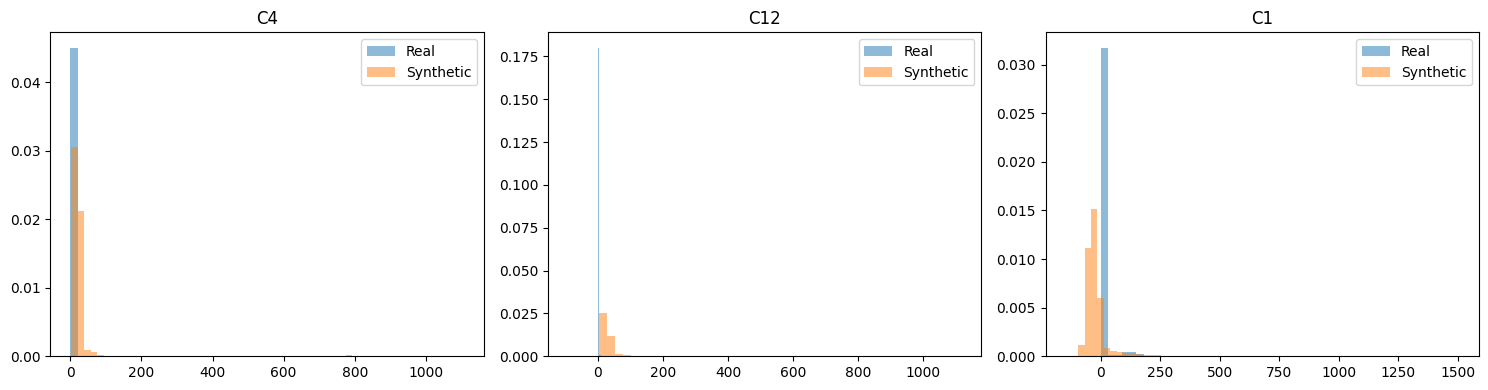

Saved to /content/feature_distributions.png


In [16]:
# Compare real vs synthetic for the top 3 most important features
import matplotlib.pyplot as plt

# Get top features from LightGBM importance
top_features = fi['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top_features):
    if feat not in FEATURE_COLS:
        continue
    real_vals = holdout[feat].values
    syn_vals  = synthetic_fraud[feat].values
    ax.hist(real_vals, bins=50, alpha=0.5, label='Real', density=True)
    ax.hist(syn_vals,  bins=50, alpha=0.5, label='Synthetic', density=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.savefig('/content/feature_distributions.png')
plt.show()
print('Saved to /content/feature_distributions.png')

In [ ]:
import zipfile
import matplotlib.pyplot as plt
from google.colab import files

img_dir = Path('/content/tgan_feature_distributions')
img_dir.mkdir(exist_ok=True)

real_fraud = holdout[holdout['Class'] == 1]

for feat in GAN_FEATURES:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(real_fraud[feat].values,      bins=60, alpha=0.5, density=True, label='Real fraud', color='steelblue')
    ax.hist(synthetic_fraud[feat].values, bins=60, alpha=0.5, density=True, label='Synthetic',  color='tomato')
    ax.set_title(f'{feat} — Real Fraud vs Synthetic')
    ax.set_xlabel(feat); ax.set_ylabel('Density'); ax.legend()
    fig.tight_layout()
    fig.savefig(img_dir / f'{feat}.png', dpi=120)
    plt.close(fig)

zip_path = '/content/tgan_feature_distributions.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(img_dir.glob('*.png')):
        zf.write(p, p.name)

print(f'Saved {len(GAN_FEATURES)} plots → {zip_path}')
files.download(zip_path)

## 13. Evaluation on Fraud Holdout

In [17]:
# ── Threshold selection on a_val (validation set only) ────────────────────
val_probs = lgb_model.predict(X_val_lgb, num_iteration=lgb_model.best_iteration)
best_thresh, best_f1 = 0.5, 0.0
thresh_rows = []
for thresh in np.arange(0.01, 0.99, 0.005):
    preds = (val_probs >= thresh).astype(int)
    f1_t  = f1_score(y_val_lgb, preds, zero_division=0)
    p     = precision_score(y_val_lgb, preds, zero_division=0)
    r     = recall_score(y_val_lgb, preds, zero_division=0)
    thresh_rows.append({'threshold': round(thresh, 4), 'f1': f1_t, 'precision': p, 'recall': r})
    if f1_t > best_f1:
        best_f1, best_thresh = f1_t, thresh

wandb.log({'eval/threshold_sweep': wandb.Table(dataframe=pd.DataFrame(thresh_rows))})
print(f'Best threshold (a_val): {best_thresh:.4f}  (val F1={best_f1:.4f})')

# ── Holdout evaluation at natural class distribution ──────────────────────
X_holdout = holdout[MODEL_FEATURES]
y_holdout = holdout['Class']

print(f'\nHoldout set: {len(holdout):,} records | '
      f'Fraud: {y_holdout.sum()} ({y_holdout.mean():.4%}) | '
      f'Normal: {(y_holdout == 0).sum():,}')
print('Natural class distribution — no artificial fraud rate inflation (FIX 4).')

t_infer = time.time()
holdout_probs = lgb_model.predict(X_holdout, num_iteration=lgb_model.best_iteration)
inference_time_ms = (time.time() - t_infer) * 1000

holdout_preds = (holdout_probs >= best_thresh).astype(int)
f1        = f1_score(y_holdout,        holdout_preds, zero_division=0)
precision = precision_score(y_holdout, holdout_preds, zero_division=0)
recall    = recall_score(y_holdout,    holdout_preds, zero_division=0)
auroc     = roc_auc_score(y_holdout,   holdout_probs)
auprc     = average_precision_score(y_holdout, holdout_probs)
mcc       = matthews_corrcoef(y_holdout, holdout_preds)
gmean     = geometric_mean_score(y_holdout, holdout_preds)

print('\n' + '=' * 55)
print('  T-GAN + LightGBM — Holdout Evaluation Results')
print('=' * 55)
print(f'  F1-Score  : {f1:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  AUROC     : {auroc:.4f}')
print(f'  AUPRC     : {auprc:.4f}')
print(f'  MCC       : {mcc:.4f}')
print(f'  G-mean    : {gmean:.4f}')
print(f'  Inference : {inference_time_ms:.2f} ms ({len(X_holdout):,} records)')
print(f'  Threshold : {best_thresh:.4f}')
print('=' * 55)
print(classification_report(y_holdout, holdout_preds, target_names=['Legit', 'Fraud']))

wandb.log({
    'holdout/f1'               : f1,
    'holdout/precision'        : precision,
    'holdout/recall'           : recall,
    'holdout/auroc'            : auroc,
    'holdout/auprc'            : auprc,
    'holdout/mcc'              : mcc,
    'holdout/gmean'            : gmean,
    'holdout/inference_time_ms': inference_time_ms,
    'holdout/threshold'        : best_thresh,
    'holdout/n_records'        : len(X_holdout),
    'holdout/fraud_rate'       : float(y_holdout.mean()),
})
wandb.run.summary.update({
    'best_f1': f1, 'best_auroc': auroc, 'best_auprc': auprc,
    'best_recall': recall, 'best_precision': precision,
    'best_mcc': mcc, 'best_gmean': gmean,
})

Best threshold (a_val): 0.6050  (val F1=0.4949)

Holdout set: 118,108 records | Fraud: 4064 (3.4409%) | Normal: 114,044
Natural class distribution — no artificial fraud rate inflation (FIX 4).

  T-GAN + LightGBM — Holdout Evaluation Results
  F1-Score  : 0.4215
  Precision : 0.5244
  Recall    : 0.3524
  AUROC     : 0.8384
  AUPRC     : 0.4183
  MCC       : 0.4135
  G-mean    : 0.5902
  Inference : 176.39 ms (118,108 records)
  Threshold : 0.6050
              precision    recall  f1-score   support

       Legit       0.98      0.99      0.98    114044
       Fraud       0.52      0.35      0.42      4064

    accuracy                           0.97    118108
   macro avg       0.75      0.67      0.70    118108
weighted avg       0.96      0.97      0.96    118108



## 14. Save Results & Finish W&B Run

In [18]:
results = {
    'model'              : 'T-GAN + LightGBM',
    'pipeline'           : 'A',
    'author'             : 'kipngeno koech (bkoech)',
    'f1'                 : round(f1, 4),
    'precision'          : round(precision, 4),
    'recall'             : round(recall, 4),
    'auroc'              : round(auroc, 4),
    'auprc'              : round(auprc, 4),
    'mcc'                : round(mcc, 4),
    'gmean'              : round(gmean, 4),
    'inference_time_ms'  : round(inference_time_ms, 2),
    'threshold'          : round(best_thresh, 4),
    'n_synthetic_fraud'  : cfg.n_synthetic_fraud,
    'quality_gates_passed': overall,
    'quality_gate_detail': {
        'mmd'         : round(mmd, 6),  'mmd_pass'    : mmd_pass,
        'jsd'         : round(jsd, 6),  'jsd_pass'    : jsd_pass,
        'novelty_dist': round(nov, 6),  'novelty_pass': nov_pass,
        'disc_auc'    : round(dauc, 4), 'disc_pass'   : disc_pass,
    },
    'wandb_run_url': wandb.run.url,
}


out_path = Path('/content/ieee_tgan_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

wandb.save(str(out_path))
print(f'Results saved to {out_path}')
print(json.dumps(results, indent=2))

wandb.finish()
print('W&B run finished.')

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Results saved to /content/ieee_tgan_results.json
{
  "model": "T-GAN + LightGBM",
  "pipeline": "A",
  "author": "kipngeno koech (bkoech)",
  "f1": 0.4215,
  "precision": 0.5244,
  "recall": 0.3524,
  "auroc": 0.8384,
  "auprc": 0.4183,
  "mcc": 0.4135,
  "gmean": 0.5902,
  "inference_time_ms": 176.39,
  "threshold": 0.605,
  "n_synthetic_fraud": 38685,
  "quality_gates_passed": false,
  "quality_gate_detail": {
    "mmd": 0.015086,
    "mmd_pass": true,
    "jsd": 0.129932,
    "jsd_pass": false,
    "novelty_dist": 98.990148,
    "novelty_pass": true,
    "disc_auc": 1.0,
    "disc_pass": false
  },
  "wandb_run_url": "https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20%20APPLICATIONS%20OF%20AI/runs/hx2xzo4f"
}


holdout/auprc,▁
holdout/auroc,▁
holdout/f1,▁
holdout/fraud_rate,▁
holdout/gmean,▁
holdout/inference_time_ms,▁
holdout/mcc,▁
holdout/n_records,▁
holdout/precision,▁
holdout/recall,▁
+26,...


W&B run finished.
